# 📊 Notebook 05 - Evaluación y Comparativa Final de Modelos

En este notebook vamos a someter a los 4 modelos entrenados previamente (XceptionNet, EfficientNet-B3, MesoInception-4 y Vision Transformers) a una evaluación exhaustiva sobre el conjunto de Test.

Dado que durante el entrenamiento guardamos dos versiones de cada modelo:
1. `best_[modelo]_acc.pth`: El que obtuvo mejor precisión pura.
2. `best_[modelo]_loss.pth`: El que minimizó el error probabilístico.

Para esta evaluación final, utilizaremos preferentemente los pesos **`_loss.pth`**, ya que en tareas de detección de Deepfakes es vital que las probabilidades emitidas por el modelo estén bien calibradas (minimizar el Log Loss), para saber con certeza cuánta "duda" tiene el modelo.

### Tabla de Métricas Utilizadas

| Métrica | Tipo | Descripción | Importancia | Por Qué Usarla |
|---------|------|-------------|-------------|---------------|
| **Accuracy** (Exactitud) | Rendimiento | Proporción de predicciones correctas sobre el total de predicciones. | Visión general de alto nivel de la corrección del modelo. | Proporciona una medida simple de qué tan a menudo el modelo acierta, pero puede ser engañosa si el conjunto de datos está desequilibrado. |
| **Precision** (Precisión) | Rendimiento | Verdaderos positivos divididos por positivos predichos (VP / (VP + FP)). | Mide la exactitud de las predicciones positivas. | Importante para minimizar falsos positivos (ej. acusar a un video real de ser un Deepfake). |
| **Recall** (Sensibilidad) | Rendimiento | Verdaderos positivos divididos por positivos reales (VP / (VP + FN)). | Mide la completitud de las predicciones positivas. | Crucial para capturar la mayor cantidad posible de Deepfakes y evitar que se escapen al filtro. |
| **Specificity** (Especificidad) | Rendimiento | Verdaderos negativos divididos por negativos reales (VN / (VN + FP)). | Mide la capacidad de identificar correctamente la clase negativa. | Vital en este TFG para ver si el modelo es demasiado "paranoico" y clasifica caras reales auténticas como falsas. |
| **F1-Score** | Rendimiento | Media armónica de precisión y recall (2 * (Precision * Recall) / (Precision + Recall)). | Equilibra la precisión y el recall. | Útil cuando los falsos positivos y falsos negativos tienen un coste similar, proporcionando una métrica única de compensación. |
| **MCC** (Matthews Correlation Coefficient) | Rendimiento | Coeficiente de correlación que evalúa verdaderos/falsos positivos y negativos (-1 a +1). | Ofrece la evaluación más equilibrada de toda la matriz de confusión. | Es una de las métricas más robustas en machine learning; solo da un valor alto si el modelo es bueno prediciendo tanto caras reales como fakes. |
| **Log Loss** (Pérdida Logarítmica) | Probabilística | Mide la precisión de las probabilidades, penalizando severamente las predicciones incorrectas con alta confianza. | Evalúa la seguridad de las salidas probabilísticas. | Recompensa modelos calibrados y castiga duramente la "sobreconfianza" en errores (ej. decir que es Deepfake al 99% y que sea real). |
| **AUC-ROC** | Probabilística | Área bajo la curva que traza la tasa de verdaderos positivos (TPR) frente a falsos positivos (FPR). | Evalúa la capacidad de discriminación en todos los umbrales posibles. | Excelente para demostrar la "inteligencia pura" del modelo separando clases, sin importar en qué punto se ponga el umbral de decisión. |
| **Brier Score** | Probabilística | Calcula el error cuadrático medio de las probabilidades pronosticadas respecto al valor real. | Evalúa la calibración exacta de las probabilidades. | Complementa al Log Loss, pero es menos extrema a la hora de penalizar errores aislados. Un modelo perfecto tiene 0.0. |
| **EER** (Equal Error Rate) | Diagnóstico | Punto o umbral exacto donde la tasa de falsa aceptación (FPR) iguala a la de falso rechazo (FNR). | Equilibra seguridad estricta y usabilidad del sistema. | Muy usada en sistemas biométricos de seguridad para encontrar el punto más equilibrado del modelo. |
| **FPR@0.5** | Clasificación | Tasa de Falsos Positivos calculada específicamente en el umbral de probabilidad del 50%. | Mide la tasa de falsas alarmas en el umbral estándar por defecto. | Permite ver rápidamente cuántas imágenes reales son etiquetadas como falsas bajo condiciones normales de predicción. |
| **Matriz de Confusión** | Diagnóstico | Tabla que muestra conteos absolutos de VP, FP, VN, FN. | Visualiza errores de predicción exactos. | Proporciona una visión detallada de los tipos de errores, ayudando a entender la tendencia del modelo (ej. si sufre de paranoia). |
| **Tiempo de Inferencia** | Rendimiento (Hardware) | Tiempo en milisegundos que toma procesar y predecir un lote de imágenes nuevas. | Mide la eficiencia computacional real. | Crítico para el despliegue del modelo en aplicaciones del mundo real (ej. análisis de video en streaming). |
| **Número de Parámetros** | Arquitectura | Conteo total de pesos entrenables en la red neuronal (en millones). | Indica la complejidad matemática del modelo. | Ayuda a evaluar el coste de memoria, la velocidad y el riesgo de sobreajuste (modelos más grandes tienden a memorizar más). |

## 📚 1. Explicación Detallada de las Métricas

Hemos dividido las métricas en 3 grandes familias para analizar cada aspecto de los modelos:

### 🎯 1.1. Métricas de Clasificación (Errores y Aciertos Directos)
* **Matriz de Confusión:** Tabla que cruza lo que el modelo predijo frente a lo que era real (VP, FP, VN, FN).
* **Accuracy (Exactitud):** Porcentaje total de imágenes clasificadas correctamente.
* **Precision (Precisión):** Si el modelo dice "Es Deepfake", ¿qué porcentaje de veces tiene razón? (Evita Falsos Positivos).
* **Recall / Sensibilidad:** De todos los Deepfakes reales, ¿cuántos logró detectar? (Evita Falsos Negativos).
* **F1-Score:** Media armónica entre Precision y Recall. Ideal para evaluar el equilibrio del modelo.
* **Especificidad (Specificity):** De todas las imágenes "Reales", ¿cuántas identificó correctamente? 
* **MCC (Matthews Correlation Coefficient):** Métrica súper robusta que va de -1 a +1. Un MCC cercano a 1 indica una predicción perfecta, 0 es aleatoria. Es excelente si las clases están desbalanceadas.

### 🔍 1.2. Métricas de Diagnóstico, Confianza y Probabilidad
* **Log Loss (Pérdida Logarítmica):** Evalúa qué tan seguro está el modelo. Si predice mal pero estaba muy seguro (ej. 99% Deepfake y era Real), el Log Loss lo penaliza brutalmente. Cuanto más cerca de 0, mejor.
* **AUC-ROC:** Mide la capacidad de distinguir entre clases. 1.0 es perfecto, 0.5 es aleatorio.
* **Brier Score:** Mide la exactitud de las predicciones probabilísticas. Es el error cuadrático medio de las probabilidades pronosticadas. Más bajo es mejor.
* **EER (Equal Error Rate):** El punto en la curva ROC donde la tasa de Falsos Positivos es idéntica a la de Falsos Negativos. En ciberseguridad y biometría, es la métrica reina. Más bajo = más seguro.
* **FPR@0.5 (Tasa de Falsas Alarmas):** Porcentaje de imágenes Reales que el modelo clasifica erróneamente como Deepfakes usando un umbral del 50%.

### ⚡ 1.3. Métricas de Rendimiento Computacional
* **Tiempo de Inferencia (ms):** Cuánto tarda en predecir una sola imagen. Vital para vídeos en tiempo real.
* **Parámetros (Millones):** Tamaño computacional del modelo. Define si cabe en un servidor o en un móvil.

In [1]:
# ==========================================
# 📦 IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, log_loss, roc_auc_score, confusion_matrix, 
                             roc_curve, brier_score_loss, matthews_corrcoef)
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluando en dispositivo: {device}")

Evaluando en dispositivo: cuda


In [2]:
# ==========================================
# 2. FUNCIONES DE EVALUACIÓN
# ==========================================

def calculate_eer(y_true, y_prob):
    """Calcula el Equal Error Rate (EER)"""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    fnr = 1 - tpr
    idx = np.nanargmin(np.absolute((fnr - fpr)))
    return fpr[idx]

def count_parameters(model):
    """Devuelve el número de parámetros entrenables en Millones"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

def evaluate_all_metrics(model_name, y_true, y_prob, inference_time_ms, num_params_m):
    """Calcula todas las métricas a partir de las probabilidades"""
    y_pred = (np.array(y_prob) >= 0.5).astype(int)
    
    # Manejo de Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn, fp, fn, tp = 0, 0, 0, 0 # Fallback por si hay errores en las etiquetas
        
    # Clasificación
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    mcc = matthews_corrcoef(y_true, y_pred)
    
    # Diagnóstico Probabilístico
    lloss = log_loss(y_true, y_prob, labels=[0, 1])
    auc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    eer = calculate_eer(y_true, y_prob)
    fpr_05 = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    return {
        "Modelo": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Specificity": specificity,
        "MCC": mcc,
        "Log Loss": lloss,
        "AUC-ROC": auc,
        "Brier Score": brier,
        "EER": eer,
        "FPR@0.5": fpr_05,
        "Tiempo Inferencia (ms)": inference_time_ms,
        "Parámetros (M)": num_params_m,
        "Confusion_Matrix": cm
    }

def run_inference(model, test_loader):
    """Pasa el DataLoader por el modelo y extrae probabilidades y tiempos"""
    model.eval()
    model.to(device)
    y_true, y_prob = [], []
    
    start_time = time.time()
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"Inferencia"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            # Ajuste de salida: Si el modelo devuelve logits (sin activación final) 
            # aplicamos Sigmoid. Si tiene 2 salidas, aplicamos Softmax.
            if outputs.shape[1] == 1:
                probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
            else:
                probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
                
            if probs.ndim == 0:
                probs = [probs]
                
            y_prob.extend(probs)
            y_true.extend(labels.numpy())
            
    total_time = time.time() - start_time
    time_per_image_ms = (total_time / max(1, len(y_true))) * 1000 
    
    return np.array(y_true), np.array(y_prob), time_per_image_ms

In [3]:
# ==========================================
# VERIFICACIÓN DEL DATASET DE TEST
# ==========================================
import pandas as pd

# Tu ruta al CSV
CSV_PATH = r'C:\TFG\Dataset_Final_Procesado\registro_datos.csv'

# Leemos el archivo y filtramos solo lo que sea 'test'
df = pd.read_csv(CSV_PATH)
df_test = df[df['split'] == 'test']

# Sacamos los números
total_test = len(df_test)
conteo_clases = df_test['label'].value_counts()

print("✅ Registro CSV cargado correctamente.")
print(f"📸 Total de imágenes para evaluar en TEST: {total_test}")
print("🏷️ Desglose por clases:")
for etiqueta, cantidad in conteo_clases.items():
    print(f"   - {etiqueta.capitalize()}: {cantidad} imágenes")

✅ Registro CSV cargado correctamente.
📸 Total de imágenes para evaluar en TEST: 5967
🏷️ Desglose por clases:
   - Real: 3000 imágenes
   - Fake: 2967 imágenes


In [4]:
# ==========================================
# EVALUACIÓN FINAL: CADA MODELO CON SU PREPROCESAMIENTO
# ==========================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import timm
import time
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Entrenando/Evaluando en: {device}")

# ---------------------------------------------------------
# 1. CLASE DATASET
# ---------------------------------------------------------
class DeepfakeDataset(Dataset):
    def __init__(self, csv_path, split='train', transform=None):
        self.df = pd.read_csv(csv_path)
        self.df = self.df[self.df['split'] == split].reset_index(drop=True)
        self.transform = transform
        self.label_dict = {'real': 0, 'fake': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label_name = self.df.iloc[idx]['label']
        label = self.label_dict[label_name]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

CSV_PATH = r'C:\TFG\Dataset_Final_Procesado\registro_datos.csv'

# ---------------------------------------------------------
# 2. TRANSFORMACIONES Y DATALOADERS INDIVIDUALES
# ---------------------------------------------------------
# XceptionNet (299x299, Normalización 0.5)
transform_xc = transforms.Compose([
    transforms.Resize((299, 299)), transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
test_loader_xc = DataLoader(DeepfakeDataset(CSV_PATH, split='test', transform=transform_xc), batch_size=32, shuffle=False)

# EfficientNet-B3 (300x300, Normalización ImageNet)
transform_eff = transforms.Compose([
    transforms.Resize((300, 300)), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_loader_eff = DataLoader(DeepfakeDataset(CSV_PATH, split='test', transform=transform_eff), batch_size=32, shuffle=False)

# MesoInception-4 (256x256, Normalización 0.5 típica)
transform_meso = transforms.Compose([
    transforms.Resize((256, 256)), transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
test_loader_meso = DataLoader(DeepfakeDataset(CSV_PATH, split='test', transform=transform_meso), batch_size=32, shuffle=False)

# Vision Transformers (224x224, Normalización 0.5)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
test_loader_vit = DataLoader(DeepfakeDataset(CSV_PATH, split='test', transform=transform_vit), batch_size=32, shuffle=False)


# ---------------------------------------------------------
# 3. CLASE MESOINCEPTION 
# ---------------------------------------------------------
class MesoInception4(nn.Module):
    def __init__(self, num_classes=2):
        super(MesoInception4, self).__init__()
        self.inception1 = self._inception_layer(3, 8, 8, 8, 8)      # 32 ch salida
        self.inception2 = self._inception_layer(32, 8, 16, 16, 8)   # 48 ch salida
        self.conv3 = nn.Conv2d(48, 64, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.1)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.maxpool2 = nn.MaxPool2d(kernel_size=4, stride=4)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def _inception_layer(self, in_channels, out1, out2, out3, out4):
        conv1 = nn.Sequential(nn.Conv2d(in_channels, out1, kernel_size=1, padding=0), nn.BatchNorm2d(out1), nn.ReLU())
        conv2 = nn.Sequential(nn.Conv2d(in_channels, out2, kernel_size=3, padding=1), nn.BatchNorm2d(out2), nn.ReLU())
        conv3 = nn.Sequential(nn.Conv2d(in_channels, out3, kernel_size=5, padding=2), nn.BatchNorm2d(out3), nn.ReLU())
        conv4 = nn.Sequential(nn.Conv2d(in_channels, out4, kernel_size=7, padding=3), nn.BatchNorm2d(out4), nn.ReLU())
        return nn.ModuleList([conv1, conv2, conv3, conv4])

    def forward(self, x):
        x = torch.cat([layer(x) for layer in self.inception1], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        x = torch.cat([layer(x) for layer in self.inception2], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        x = self.relu(self.bn1(self.conv3(x)))
        x = self.maxpool1(x)
        x = self.relu(self.bn2(self.conv4(x)))
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.leaky_relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# ---------------------------------------------------------
# 4. FUNCIÓN INFERENCIA ÚNICA (Ya no hace falta la de ViT separada)
# ---------------------------------------------------------
def run_inference(model, test_loader, model_name, invertir_probabilidades=False):
    model.eval()
    model.to(device)
    y_true, y_prob = [], []
    start_time = time.time()
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"Inferencia {model_name}"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            if outputs.shape[1] == 1:
                probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
            else:
                probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
                
            if probs.ndim == 0: probs = [probs]
            
            if invertir_probabilidades:
                probs = 1.0 - np.array(probs)
                
            y_prob.extend(probs)
            y_true.extend(labels.numpy())
            
    time_per_image_ms = ((time.time() - start_time) / max(1, len(y_true))) * 1000 
    return np.array(y_true), np.array(y_prob), time_per_image_ms

# ---------------------------------------------------------
# 5. EJECUCIÓN
# ---------------------------------------------------------
resultados = []

path_xception = r"C:\TFG\modelos\best_xception_loss.pth"
path_effnet = r"C:\TFG\modelos\best_effnet_loss.pth" 
path_meso = r"C:\TFG\modelos\best_mesoinception_mejorado_loss.pth"
path_vit = r"C:\TFG\modelos\best_vit_loss.pth"

# 1. XceptionNet (Usa su loader: test_loader_xc)
try:
    model_xc = timm.create_model('xception', pretrained=False, num_classes=2)
    model_xc.load_state_dict(torch.load(path_xception, map_location=device))
    y_t, y_p, t_ms = run_inference(model_xc, test_loader_xc, "XceptionNet", invertir_probabilidades=False)
    resultados.append(evaluate_all_metrics("1. XceptionNet", y_t, y_p, t_ms, count_parameters(model_xc)))
except Exception as e: print(f"Error XceptionNet: {e}")

# 2. EfficientNet (Usa su loader: test_loader_eff)
try:
    model_eff = timm.create_model('tf_efficientnet_b3', pretrained=False, num_classes=2)
    model_eff.load_state_dict(torch.load(path_effnet, map_location=device))
    y_t, y_p, t_ms = run_inference(model_eff, test_loader_eff, "EfficientNet", invertir_probabilidades=False)
    resultados.append(evaluate_all_metrics("2. EfficientNet-B3", y_t, y_p, t_ms, count_parameters(model_eff)))
except Exception as e: print(f"Error EfficientNet: {e}")

# 3. MesoInception (Usa su loader: test_loader_meso)
try:
    model_meso = MesoInception4(num_classes=2)
    model_meso.load_state_dict(torch.load(path_meso, map_location=device))
    y_t, y_p, t_ms = run_inference(model_meso, test_loader_meso, "MesoInception", invertir_probabilidades=False)
    resultados.append(evaluate_all_metrics("3. MesoInception-4", y_t, y_p, t_ms, count_parameters(model_meso)))
except Exception as e: print(f"Error MesoInception: {e}")

# 4. ViT (Usa su loader: test_loader_vit)
# (Puedes comentarlo con # si no quieres esperar la hora que tarda)
try:
    model_vit = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)
    model_vit.load_state_dict(torch.load(path_vit, map_location=device))
    y_t, y_p, t_ms = run_inference(model_vit, test_loader_vit, "ViT", invertir_probabilidades=False)
    resultados.append(evaluate_all_metrics("4. Vision Transformers", y_t, y_p, t_ms, count_parameters(model_vit)))
except Exception as e: print(f"Error ViT: {e}")

print("\n✅ Evaluaciones completadas con el preprocesamiento exacto de cada modelo.")

🔥 Entrenando/Evaluando en: cuda


Inferencia ViT: 100%|██████████| 187/187 [00:52<00:00,  3.54it/s]


✅ Evaluaciones completadas con el preprocesamiento exacto de cada modelo.


## TABLA DE MÉTRICAS

In [5]:
# ==========================================
# 4. TABLA COMPARATIVA DE MÉTRICAS (COLORES CORREGIDOS)
# ==========================================
import pandas as pd
import seaborn as sns

# Por si acaso necesitas volver a crear la tabla desde 'resultados'
if 'df_resultados' not in locals():
    df_resultados = pd.DataFrame(resultados)
    
matrices = df_resultados[["Modelo", "Confusion_Matrix"]].copy()
df_metricas = df_resultados.drop("Confusion_Matrix", axis=1)
df_metricas.set_index("Modelo", inplace=True)

# 🟢 Verde: Cuanto más ALTO, mejor (Más oscuro = Mejor)
cm_good = sns.light_palette("seagreen", as_cmap=True)

# 🔴 Rojo: Cuanto más BAJO, mejor (Más oscuro = PEOR / Peligro)
# ¡Corregido! Ya no tiene el reverse=True
cm_bad = sns.light_palette("indianred", as_cmap=True)

display(df_metricas.style
        .background_gradient(cmap=cm_good, subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'MCC', 'AUC-ROC'])
        .background_gradient(cmap=cm_bad, subset=['Log Loss', 'Brier Score', 'EER', 'FPR@0.5', 'Tiempo Inferencia (ms)', 'Parámetros (M)'])
        .format("{:.4f}"))

,Accuracy,Precision,Recall,F1-Score,Specificity,MCC,Log Loss,AUC-ROC,Brier Score,EER,FPR@0.5,Tiempo Inferencia (ms),Parámetros (M)
Modelo,,,,,,,,,,,,,
1. XceptionNet,0.8453,0.8576,0.8261,0.8415,0.8643,0.6910,0.3504,0.9283,0.1093,0.1550,0.1357,7.2926,20.8111
2. EfficientNet-B3,0.8034,0.7666,0.8692,0.8147,0.7383,0.6126,0.4304,0.8951,0.1380,0.1843,0.2617,6.6843,10.6993
3. MesoInception-4,0.6630,0.7314,0.5093,0.6004,0.8150,0.3408,0.6130,0.7342,0.2122,0.3283,0.1850,3.5254,1.2614
4. Vision Transformers,0.9083,0.9559,0.8551,0.9027,0.9610,0.8211,0.2460,0.9687,0.0698,0.0850,0.0390,8.8503,85.8002


# ACCURACY

XceptionNet Accuracy: 0.8453
EfficientNet Accuracy: 0.8034
MesoInception Accuracy: 0.6630
ViT Accuracy: 0.9083

Comparación de Accuracy:
          Modelo  Accuracy
0    XceptionNet    0.8453
1   EfficientNet    0.8034
2  MesoInception    0.6630
3            ViT    0.9083


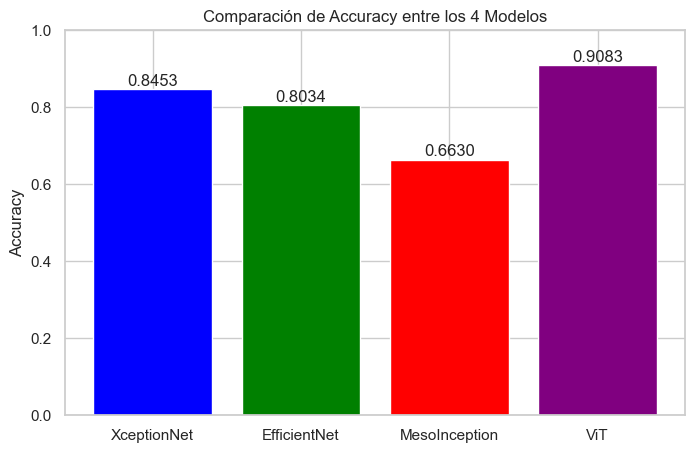


Análisis: El modelo con mayor accuracy es el ViT con 0.9083, mientras que el MesoInception tiene el menor con 0.6630. Accuracy mide la proporción de predicciones correctas, pero considera el contexto del dataset para interpretarlo correctamente.


In [6]:
# Análisis de la Métrica Accuracy para los 4 Modelos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Valores de Accuracy obtenidos de las tablas de resultados en los notebooks 01-04
accuracy_model1 = 0.8453  # Accuracy del Modelo 1 (XceptionNet, notebook 01)
accuracy_model2 = 0.8034  # Accuracy del Modelo 2 (EfficientNet, notebook 02)
accuracy_model3 = 0.6630  # Accuracy del Modelo 3 (MesoInception, notebook 03)
accuracy_model4 = 0.9083  # Accuracy del Modelo 4 (ViT, notebook 04)

# Lista de accuracies y nombres
accuracies = [accuracy_model1, accuracy_model2, accuracy_model3, accuracy_model4]
model_names = ['XceptionNet', 'EfficientNet', 'MesoInception', 'ViT']

# Imprimir accuracies
for name, acc in zip(model_names, accuracies):
    print(f"{name} Accuracy: {acc:.4f}")

# Comparación en un DataFrame
df_accuracy = pd.DataFrame({'Modelo': model_names, 'Accuracy': accuracies})
print("\nComparación de Accuracy:")
print(df_accuracy)

# Gráfico de barras para comparación
plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies, color=['blue', 'green', 'red', 'purple'])
plt.ylabel('Accuracy')
plt.title('Comparación de Accuracy entre los 4 Modelos')
plt.ylim(0, 1)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f'{acc:.4f}', ha='center')
plt.show()

# Análisis breve
print("\nAnálisis: El modelo con mayor accuracy es el ViT con {:.4f}, mientras que el MesoInception tiene el menor con {:.4f}. Accuracy mide la proporción de predicciones correctas, pero considera el contexto del dataset para interpretarlo correctamente.".format(max(accuracies), min(accuracies)))

# PRECISION

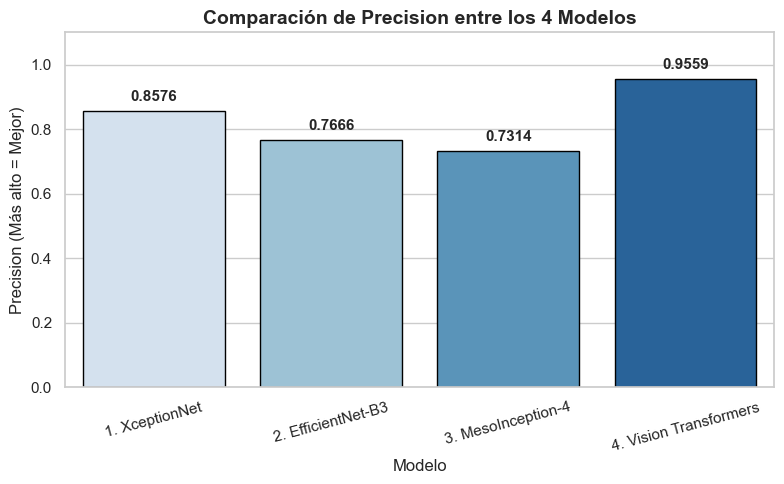

Análisis: El modelo con mayor Precision es 4. Vision Transformers (0.9559). Esto significa que es el que comete menos Falsas Alarmas al etiquetar imágenes reales.


In [7]:
# Gráfica de Precision
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df_metricas.index, y=df_metricas['Precision'], palette='Blues', edgecolor='black')

plt.title('Comparación de Precision entre los 4 Modelos', fontsize=14, fontweight='bold')
plt.ylabel('Precision (Más alto = Mejor)')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)

# Poner los valores exactos sobre las barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# Análisis automático
mejor_mod = df_metricas['Precision'].idxmax()
peor_mod = df_metricas['Precision'].idxmin()
print(f"Análisis: El modelo con mayor Precision es {mejor_mod} ({df_metricas['Precision'].max():.4f}). Esto significa que es el que comete menos Falsas Alarmas al etiquetar imágenes reales.")

# RECALL

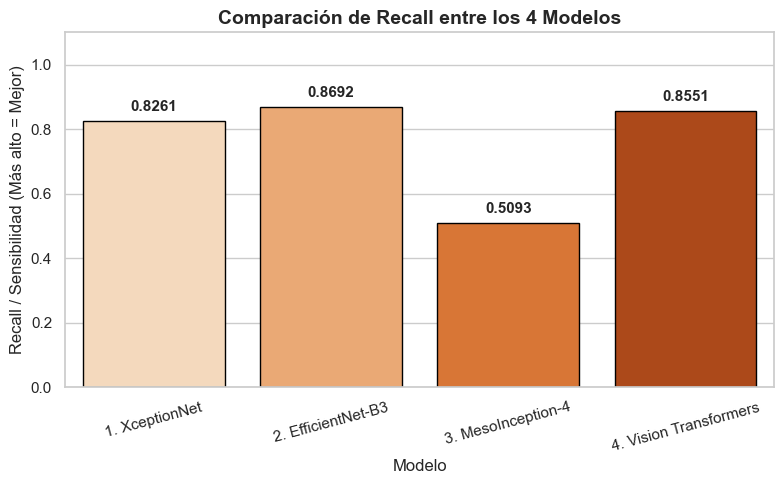

Análisis: El modelo con mayor Recall es 2. EfficientNet-B3 (0.8692). Es el modelo al que se le escapan menos deepfakes.


In [8]:
# Gráfica de Recall
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df_metricas.index, y=df_metricas['Recall'], palette='Oranges', edgecolor='black')

plt.title('Comparación de Recall entre los 4 Modelos', fontsize=14, fontweight='bold')
plt.ylabel('Recall / Sensibilidad (Más alto = Mejor)')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

mejor_mod = df_metricas['Recall'].idxmax()
print(f"Análisis: El modelo con mayor Recall es {mejor_mod} ({df_metricas['Recall'].max():.4f}). Es el modelo al que se le escapan menos deepfakes.")

# F1-SCORE

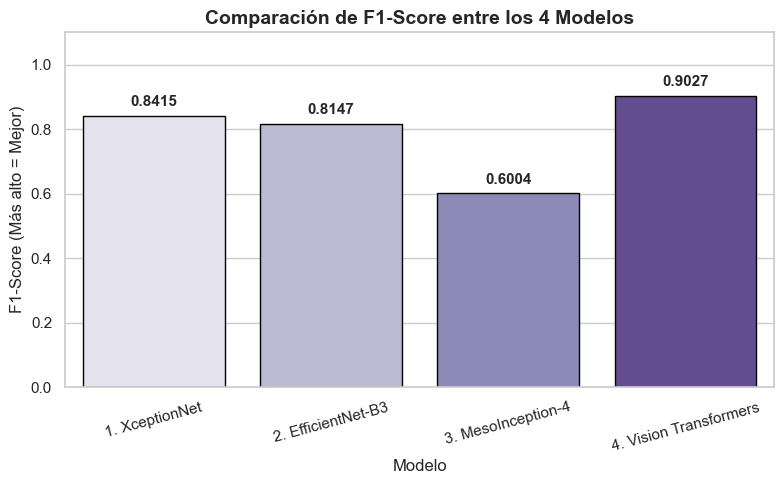

Análisis: El modelo más equilibrado globalmente según el F1-Score es 4. Vision Transformers con 0.9027.


In [9]:
# Gráfica de F1-Score
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df_metricas.index, y=df_metricas['F1-Score'], palette='Purples', edgecolor='black')

plt.title('Comparación de F1-Score entre los 4 Modelos', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score (Más alto = Mejor)')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

mejor_mod = df_metricas['F1-Score'].idxmax()
print(f"Análisis: El modelo más equilibrado globalmente según el F1-Score es {mejor_mod} con {df_metricas['F1-Score'].max():.4f}.")

# LOG LOSS

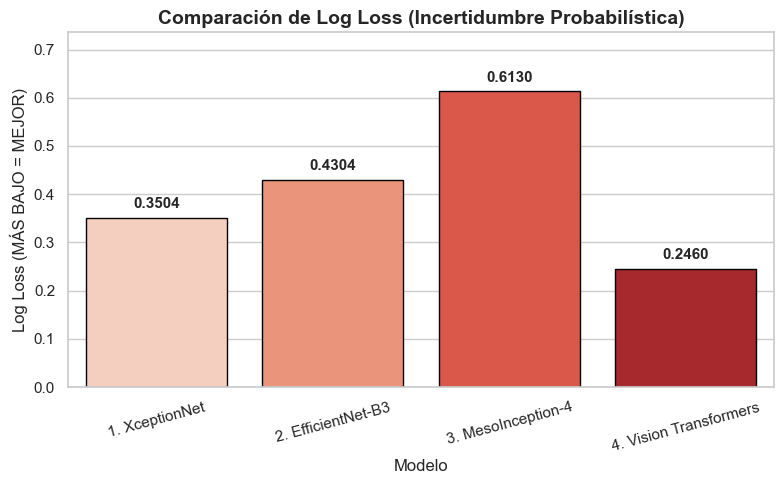

Análisis: El modelo más seguro de sus predicciones (menor error probabilístico) es 4. Vision Transformers con 0.2460.


In [10]:
# Gráfica de Log Loss
plt.figure(figsize=(8, 5))
# Usamos rojos porque es una métrica de error (queremos que sea baja)
ax = sns.barplot(x=df_metricas.index, y=df_metricas['Log Loss'], palette='Reds', edgecolor='black')

plt.title('Comparación de Log Loss (Incertidumbre Probabilística)', fontsize=14, fontweight='bold')
plt.ylabel('Log Loss (MÁS BAJO = MEJOR)')
# No limitamos la Y a 1.0 porque el Log Loss puede ser mayor
plt.ylim(0, df_metricas['Log Loss'].max() * 1.2) 
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# Aquí buscamos el MÍNIMO, no el máximo
mejor_mod = df_metricas['Log Loss'].idxmin() 
print(f"Análisis: El modelo más seguro de sus predicciones (menor error probabilístico) es {mejor_mod} con {df_metricas['Log Loss'].min():.4f}.")

# AUC-ROC

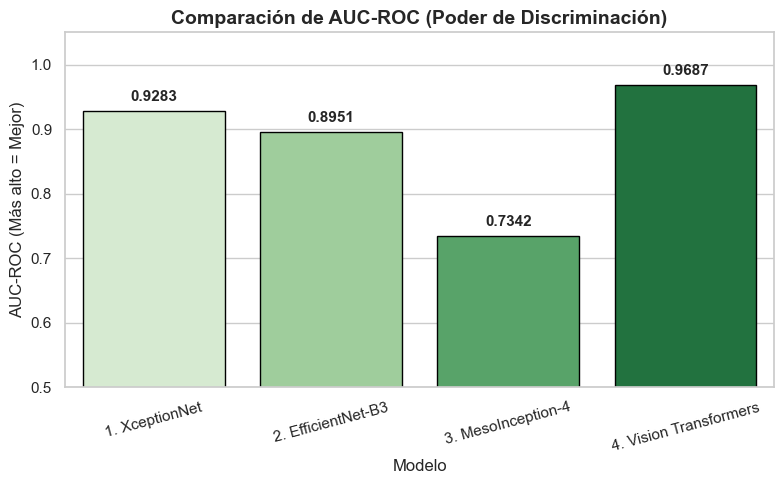

Análisis: El modelo con mayor capacidad matemática para separar imágenes Reales de Falsas es 4. Vision Transformers con un AUC de 0.9687.


In [11]:
# Gráfica de AUC-ROC
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df_metricas.index, y=df_metricas['AUC-ROC'], palette='Greens', edgecolor='black')

plt.title('Comparación de AUC-ROC (Poder de Discriminación)', fontsize=14, fontweight='bold')
plt.ylabel('AUC-ROC (Más alto = Mejor)')
plt.ylim(0.5, 1.05) # Empezamos en 0.5 porque un modelo al azar saca 0.5
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

mejor_mod = df_metricas['AUC-ROC'].idxmax()
print(f"Análisis: El modelo con mayor capacidad matemática para separar imágenes Reales de Falsas es {mejor_mod} con un AUC de {df_metricas['AUC-ROC'].max():.4f}.")

# SPECIFICITY

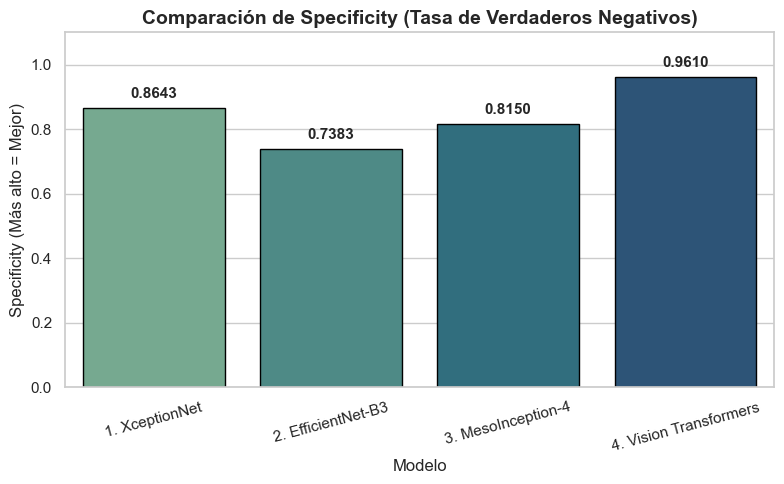

Análisis: El modelo con mayor Specificity es 4. Vision Transformers (0.9610). Es el que mejor identifica las imágenes Reales, minimizando el bloqueo de contenido auténtico.


In [12]:
# Gráfica de Specificity
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df_metricas.index, y=df_metricas['Specificity'], palette='crest', edgecolor='black')

plt.title('Comparación de Specificity (Tasa de Verdaderos Negativos)', fontsize=14, fontweight='bold')
plt.ylabel('Specificity (Más alto = Mejor)')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

mejor_mod = df_metricas['Specificity'].idxmax()
print(f"Análisis: El modelo con mayor Specificity es {mejor_mod} ({df_metricas['Specificity'].max():.4f}). Es el que mejor identifica las imágenes Reales, minimizando el bloqueo de contenido auténtico.")

## MCC (Matthews Correlation Coefficient)

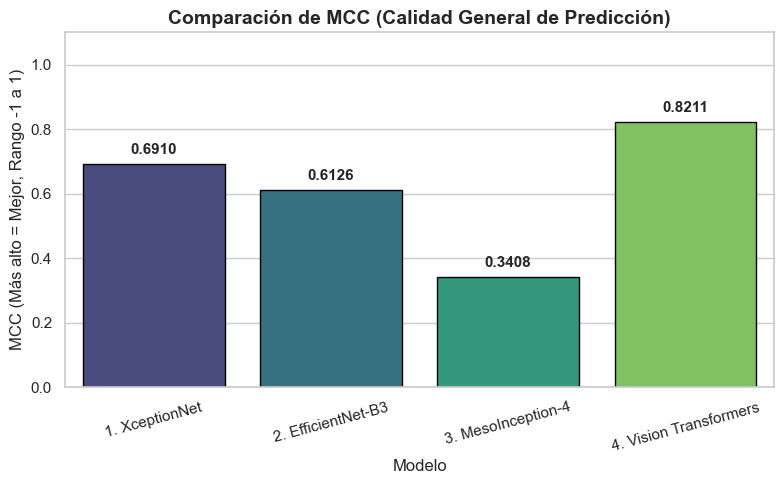

Análisis: El modelo con mejor coeficiente MCC es 4. Vision Transformers (0.8211), lo que indica que es el más equilibrado globalmente considerando Verdaderos y Falsos Positivos/Negativos.


In [13]:
# Gráfica de MCC
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df_metricas.index, y=df_metricas['MCC'], palette='viridis', edgecolor='black')

plt.title('Comparación de MCC (Calidad General de Predicción)', fontsize=14, fontweight='bold')
plt.ylabel('MCC (Más alto = Mejor, Rango -1 a 1)')
plt.ylim(0, 1.1) # Asumimos que no hay negativos en tu caso
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

mejor_mod = df_metricas['MCC'].idxmax()
print(f"Análisis: El modelo con mejor coeficiente MCC es {mejor_mod} ({df_metricas['MCC'].max():.4f}), lo que indica que es el más equilibrado globalmente considerando Verdaderos y Falsos Positivos/Negativos.")

# BRIER SCORE

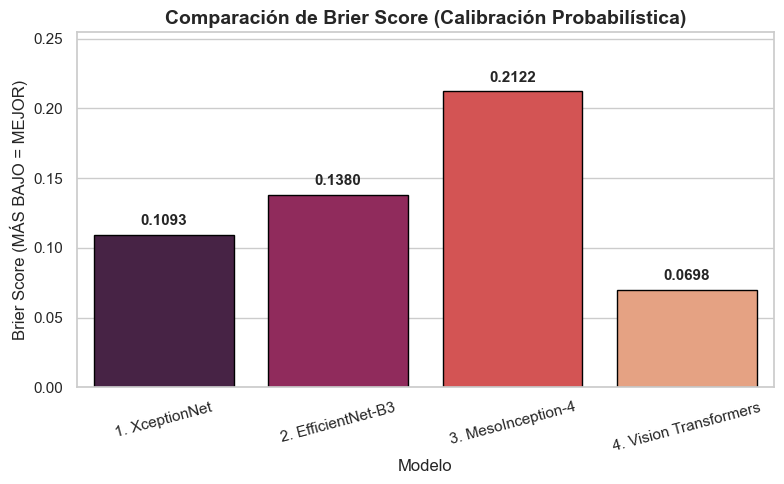

Análisis: 4. Vision Transformers tiene el menor Brier Score (0.0698). Sus probabilidades predichas coinciden muy bien con la realidad (está muy bien calibrado).


In [14]:
# Gráfica de Brier Score
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df_metricas.index, y=df_metricas['Brier Score'], palette='rocket', edgecolor='black')

plt.title('Comparación de Brier Score (Calibración Probabilística)', fontsize=14, fontweight='bold')
plt.ylabel('Brier Score (MÁS BAJO = MEJOR)')
plt.ylim(0, df_metricas['Brier Score'].max() * 1.2)
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

mejor_mod = df_metricas['Brier Score'].idxmin()
print(f"Análisis: {mejor_mod} tiene el menor Brier Score ({df_metricas['Brier Score'].min():.4f}). Sus probabilidades predichas coinciden muy bien con la realidad (está muy bien calibrado).")

# EER (Equal Error Rate)

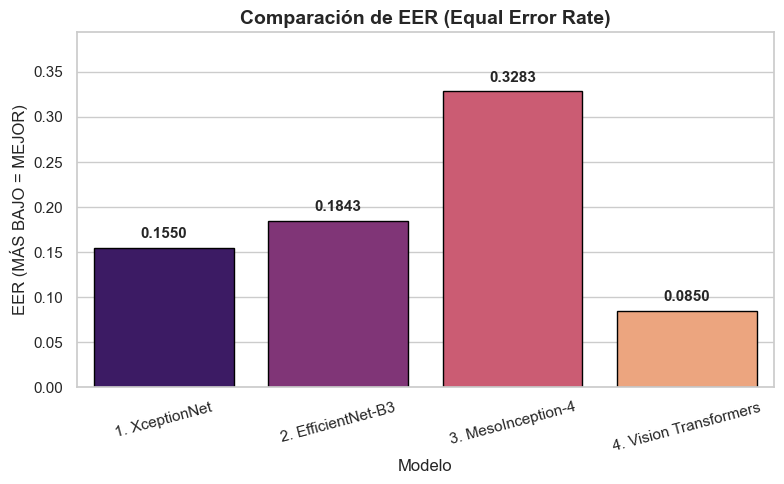

Análisis: El modelo con la tasa de error más baja en su punto de equilibrio es 4. Vision Transformers (EER = 0.0850).


In [15]:
# Gráfica de EER
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df_metricas.index, y=df_metricas['EER'], palette='magma', edgecolor='black')

plt.title('Comparación de EER (Equal Error Rate)', fontsize=14, fontweight='bold')
plt.ylabel('EER (MÁS BAJO = MEJOR)')
plt.ylim(0, df_metricas['EER'].max() * 1.2)
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

mejor_mod = df_metricas['EER'].idxmin()
print(f"Análisis: El modelo con la tasa de error más baja en su punto de equilibrio es {mejor_mod} (EER = {df_metricas['EER'].min():.4f}).")

# FPR@0.5 (Tasa de Falsos Positivos)

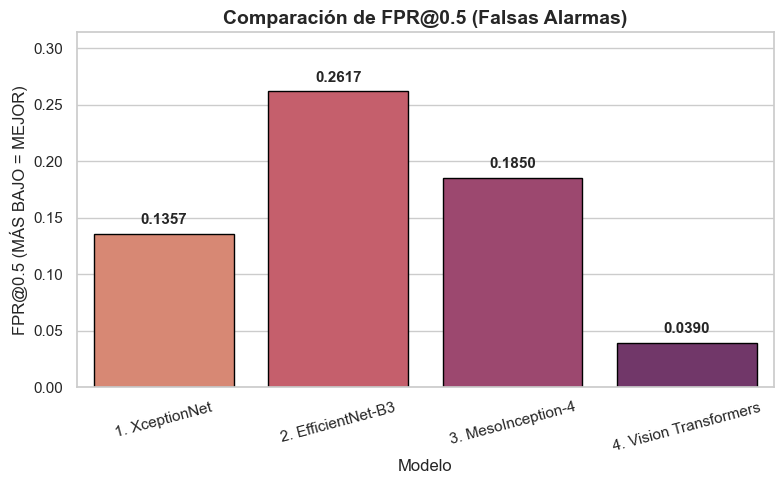

Análisis: 4. Vision Transformers es el modelo que genera menos molestias al usuario legítimo, con una tasa de falsas alarmas de solo 0.0390 (3.9%).


In [16]:
# Gráfica de FPR@0.5
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df_metricas.index, y=df_metricas['FPR@0.5'], palette='flare', edgecolor='black')

plt.title('Comparación de FPR@0.5 (Falsas Alarmas)', fontsize=14, fontweight='bold')
plt.ylabel('FPR@0.5 (MÁS BAJO = MEJOR)')
plt.ylim(0, df_metricas['FPR@0.5'].max() * 1.2)
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

mejor_mod = df_metricas['FPR@0.5'].idxmin()
print(f"Análisis: {mejor_mod} es el modelo que genera menos molestias al usuario legítimo, con una tasa de falsas alarmas de solo {df_metricas['FPR@0.5'].min():.4f} ({(df_metricas['FPR@0.5'].min()*100):.1f}%).")

# TIEMPO DE INFERENCIA

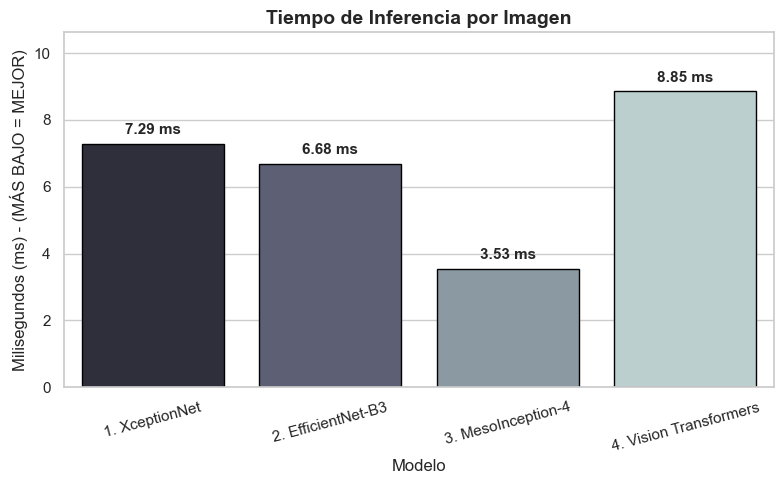

Análisis: El modelo más rápido es 3. MesoInception-4, procesando cada imagen en 3.53 milisegundos. Es el candidato ideal para entornos Edge.


In [17]:
# Gráfica de Tiempo de Inferencia
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df_metricas.index, y=df_metricas['Tiempo Inferencia (ms)'], palette='bone', edgecolor='black')

plt.title('Tiempo de Inferencia por Imagen', fontsize=14, fontweight='bold')
plt.ylabel('Milisegundos (ms) - (MÁS BAJO = MEJOR)')
plt.ylim(0, df_metricas['Tiempo Inferencia (ms)'].max() * 1.2)
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} ms", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

mejor_mod = df_metricas['Tiempo Inferencia (ms)'].idxmin()
print(f"Análisis: El modelo más rápido es {mejor_mod}, procesando cada imagen en {df_metricas['Tiempo Inferencia (ms)'].min():.2f} milisegundos. Es el candidato ideal para entornos Edge.")

# PARÁMETROS (M)

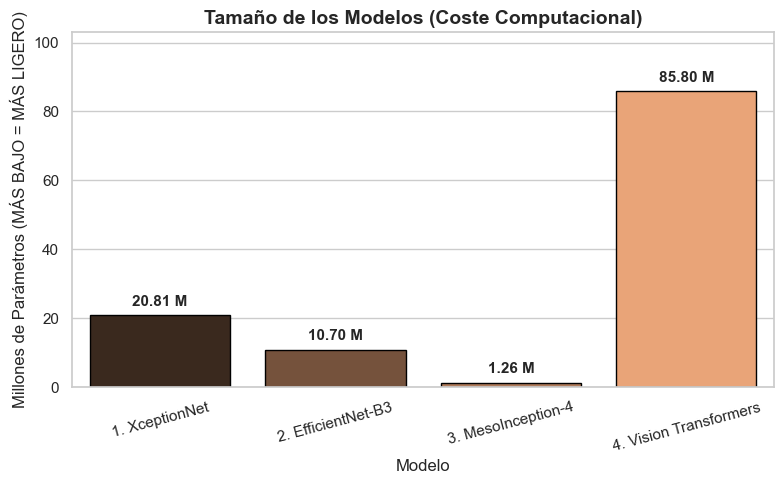

Análisis: La arquitectura más ligera es 3. MesoInception-4 con solo 1.26 millones de parámetros, en contraste con el elevado coste de arquitecturas más profundas.


In [18]:
# Gráfica de Parámetros
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=df_metricas.index, y=df_metricas['Parámetros (M)'], palette='copper', edgecolor='black')

plt.title('Tamaño de los Modelos (Coste Computacional)', fontsize=14, fontweight='bold')
plt.ylabel('Millones de Parámetros (MÁS BAJO = MÁS LIGERO)')
plt.ylim(0, df_metricas['Parámetros (M)'].max() * 1.2)
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} M", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

mejor_mod = df_metricas['Parámetros (M)'].idxmin()
print(f"Análisis: La arquitectura más ligera es {mejor_mod} con solo {df_metricas['Parámetros (M)'].min():.2f} millones de parámetros, en contraste con el elevado coste de arquitecturas más profundas.")

## métricas de clasificación (Accuracy, Precision, Recall, F1-Score)

<Figure size 1200x600 with 0 Axes>

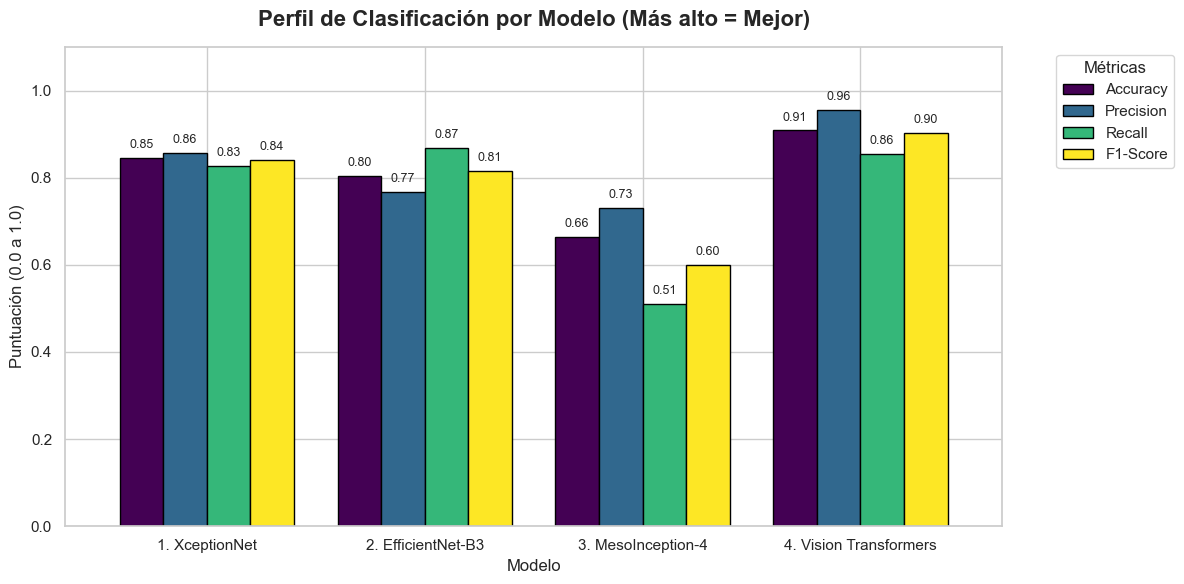

In [19]:
# ==========================================
# GRÁFICO 1: PERFIL DE CLASIFICACIÓN (Barras Agrupadas)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filtramos solo las métricas de rendimiento positivas
df_clf = df_metricas[['Accuracy', 'Precision', 'Recall', 'F1-Score']]

# Configuramos el estilo
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Dibujamos las barras agrupadas
ax = df_clf.plot(kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black', width=0.8)

plt.title('Perfil de Clasificación por Modelo (Más alto = Mejor)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Puntuación (0.0 a 1.0)', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, 1.1)
plt.legend(title='Métricas', bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadir los valores encima de cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=9, xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

## métricas de Error/Incertidumbre (Log Loss y Brier Score)

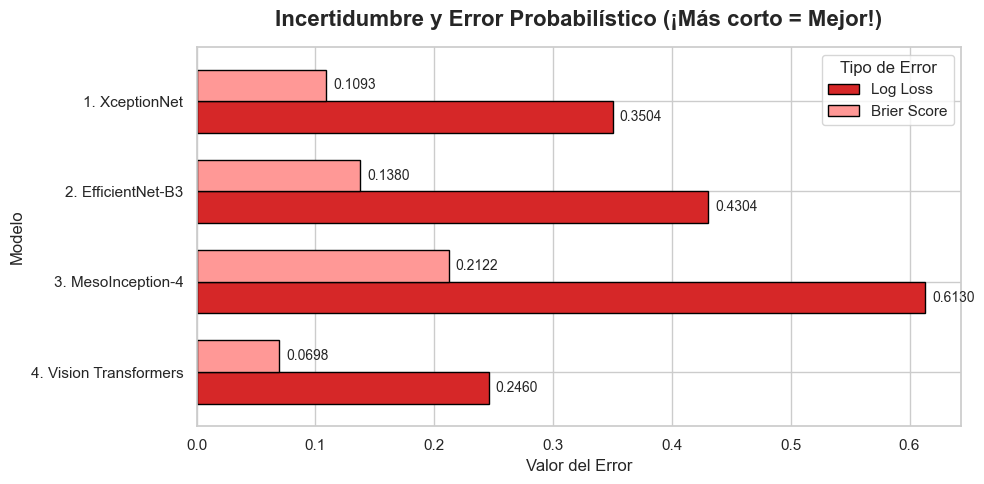

In [20]:
# ==========================================
# GRÁFICO 2: ANÁLISIS DE ERROR (Barras Horizontales)
# ==========================================
# Filtramos las métricas de error
df_errores = df_metricas[['Log Loss', 'Brier Score']].copy()

# Invertimos el orden para que el mejor quede arriba visualmente
df_errores = df_errores.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 5))

df_errores.plot(kind='barh', ax=ax, color=['#d62728', '#ff9896'], edgecolor='black', width=0.7)

plt.title('Incertidumbre y Error Probabilístico (¡Más corto = Mejor!)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Valor del Error', fontsize=12)
plt.ylabel('Modelo', fontsize=12)
plt.legend(title='Tipo de Error')

# Añadimos los valores a la derecha de las barras
for p in ax.patches:
    ax.annotate(f"{p.get_width():.4f}", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=10, xytext=(5, 0), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

## Para el AUC-ROC (Poder de Discriminación)

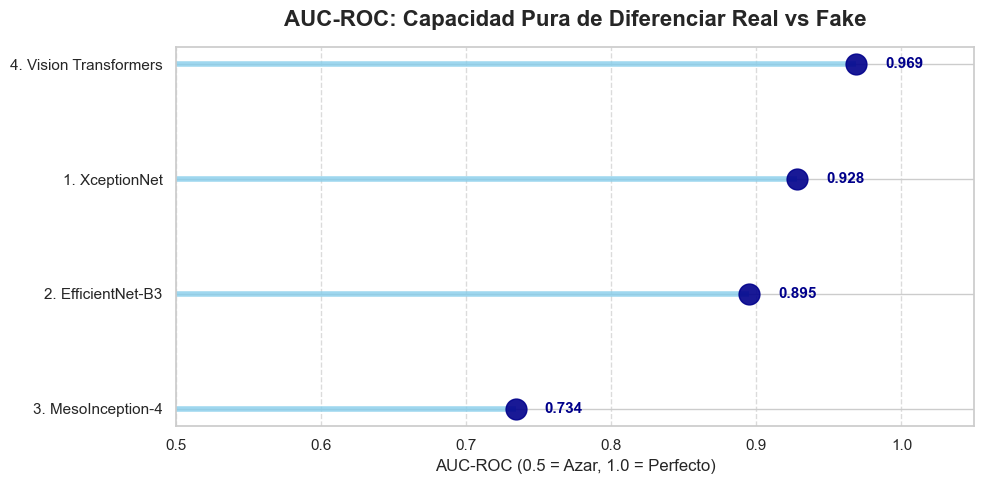

In [21]:
# ==========================================
# GRÁFICO 3: AUC-ROC (Lollipop Chart / Piruletas)
# ==========================================
# Ordenamos los modelos de menor a mayor AUC-ROC para el efecto visual
df_auc = df_metricas[['AUC-ROC']].sort_values(by='AUC-ROC')
modelos_auc = df_auc.index

plt.figure(figsize=(10, 5))

# Dibujar las líneas (los "palos")
plt.hlines(y=modelos_auc, xmin=0.5, xmax=df_auc['AUC-ROC'], color='skyblue', alpha=0.8, linewidth=4)

# Dibujar los puntos (los "caramelos")
plt.plot(df_auc['AUC-ROC'], modelos_auc, "o", markersize=15, color='darkblue', alpha=0.9)

plt.title('AUC-ROC: Capacidad Pura de Diferenciar Real vs Fake', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('AUC-ROC (0.5 = Azar, 1.0 = Perfecto)', fontsize=12)
plt.xlim(0.5, 1.05) # Empezamos en 0.5 porque un modelo inútil saca 0.5
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadir los números dentro de los círculos
for i, valor in enumerate(df_auc['AUC-ROC']):
    plt.text(valor + 0.02, i, f"{valor:.3f}", va='center', fontsize=11, fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()

## Para Coste vs Rendimiento (El resumen final)

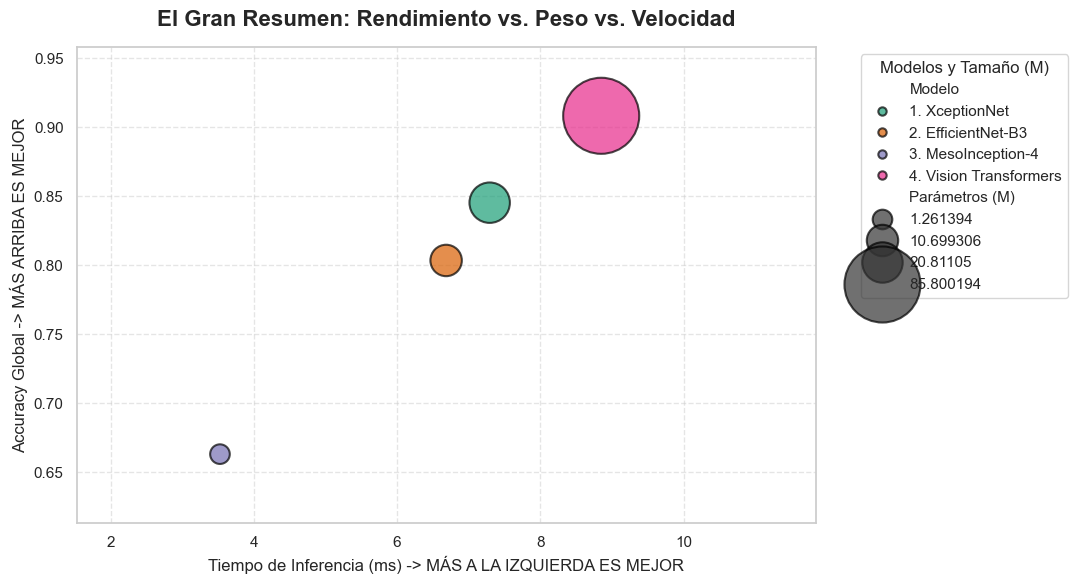

In [22]:
# ==========================================
# GRÁFICO 4: BUBBLE CHART (Eficiencia vs Rendimiento)
# ==========================================
plt.figure(figsize=(11, 6))

scatter = sns.scatterplot(
    data=df_metricas, 
    x="Tiempo Inferencia (ms)", 
    y="Accuracy", 
    size="Parámetros (M)", 
    hue=df_metricas.index,
    sizes=(200, 3000), # Rango de tamaño de las burbujas
    alpha=0.7, 
    palette="Dark2",
    edgecolor="black",
    linewidth=1.5
)

plt.title("El Gran Resumen: Rendimiento vs. Peso vs. Velocidad", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Tiempo de Inferencia (ms) -> MÁS A LA IZQUIERDA ES MEJOR", fontsize=12)
plt.ylabel("Accuracy Global -> MÁS ARRIBA ES MEJOR", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Ajuste automático de los límites para que las burbujas no se corten
plt.xlim(df_metricas["Tiempo Inferencia (ms)"].min() - 2, df_metricas["Tiempo Inferencia (ms)"].max() + 3)
plt.ylim(df_metricas["Accuracy"].min() - 0.05, df_metricas["Accuracy"].max() + 0.05)

# Arreglar la leyenda para que no estorbe
h, l = scatter.get_legend_handles_labels()
plt.legend(h, l, bbox_to_anchor=(1.05, 1), loc='upper left', title="Modelos y Tamaño (M)")

plt.tight_layout()
plt.show()

# Las Matrices de Confusión de cada uno de los modeolos

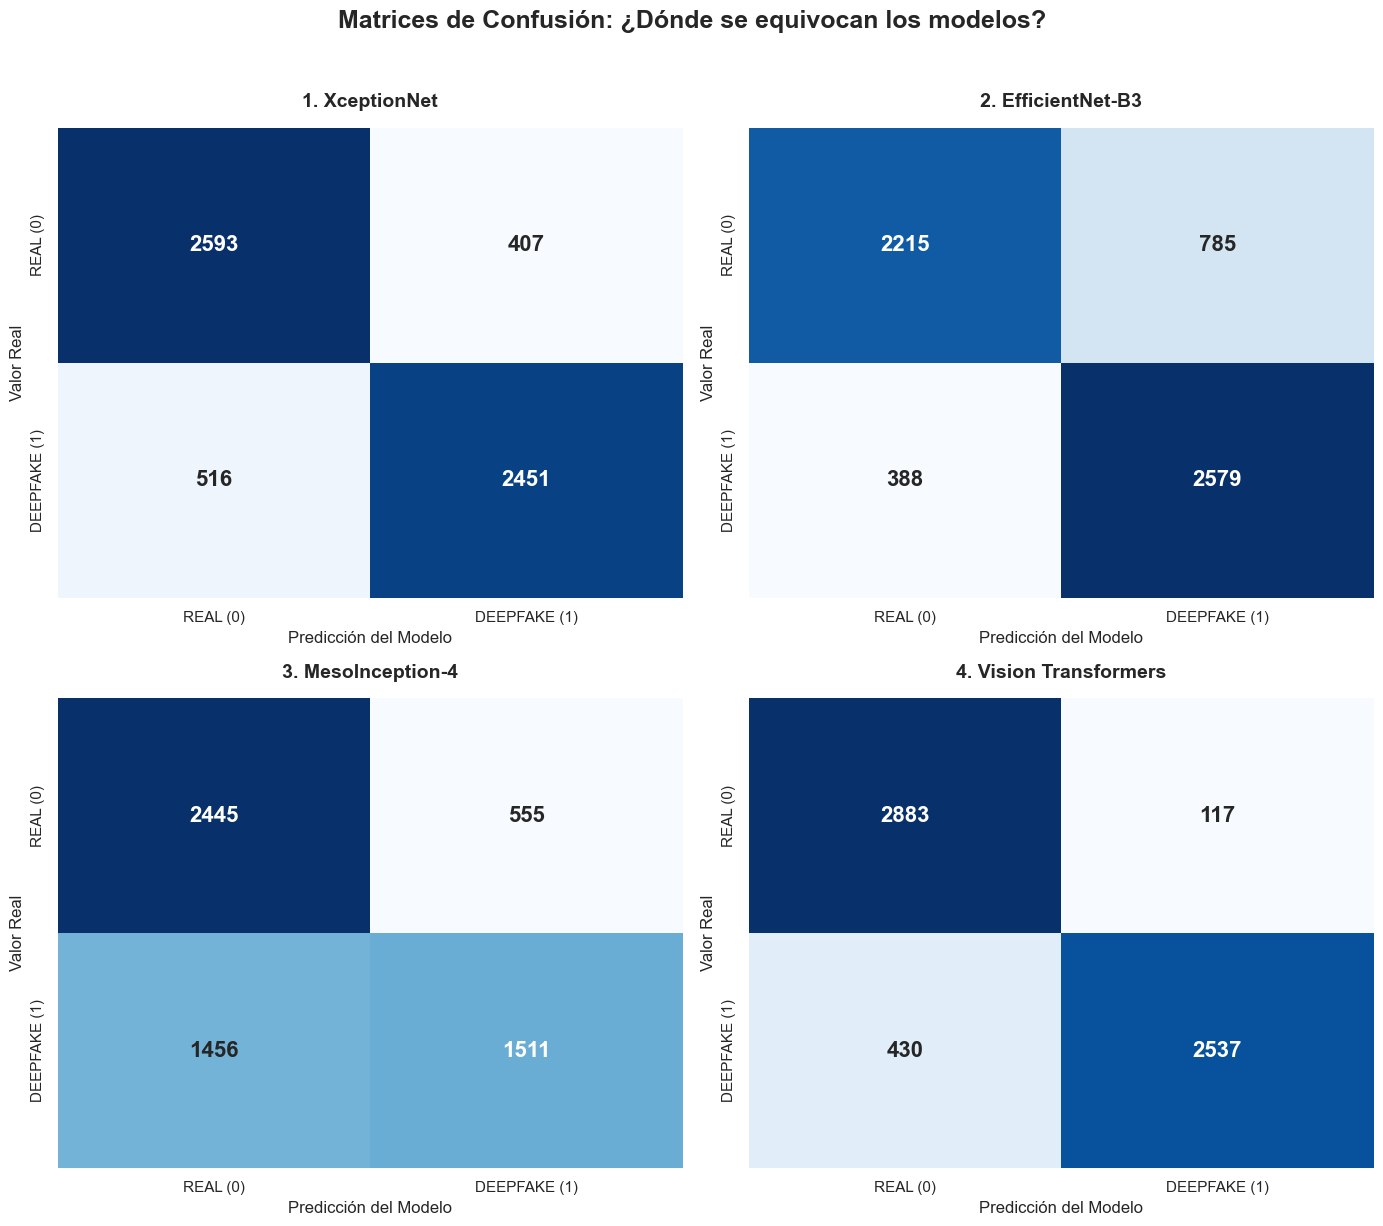

Análisis: Aquí podemos ver los Falsos Positivos (esquina superior derecha) y los Falsos Negativos (esquina inferior izquierda) en valores absolutos.


In [23]:
# ==========================================
# DIAGNÓSTICO: MATRICES DE CONFUSIÓN (2x2)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos una figura grande con 4 subgráficos (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Matrices de Confusión: ¿Dónde se equivocan los modelos?', fontsize=18, fontweight='bold', y=1.02)

# Aplanamos la matriz de ejes para iterar fácilmente
axes = axes.flatten()

# Iteramos sobre los modelos guardados en la variable 'matrices'
for i, row in matrices.iterrows():
    cm = row["Confusion_Matrix"]
    
    # Dibujamos el Heatmap
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', ax=axes[i], 
                cbar=False, annot_kws={"size": 16, "weight": "bold"})
    
    axes[i].set_title(row["Modelo"], fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel("Predicción del Modelo", fontsize=12)
    axes[i].set_ylabel("Valor Real", fontsize=12)
    
    # Etiquetas de las clases
    axes[i].set_xticklabels(['REAL (0)', 'DEEPFAKE (1)'])
    axes[i].set_yticklabels(['REAL (0)', 'DEEPFAKE (1)'])

plt.tight_layout()
plt.show()

print("Análisis: Aquí podemos ver los Falsos Positivos (esquina superior derecha) y los Falsos Negativos (esquina inferior izquierda) en valores absolutos.")

# El Gráfico de Radar (Spider Plot)

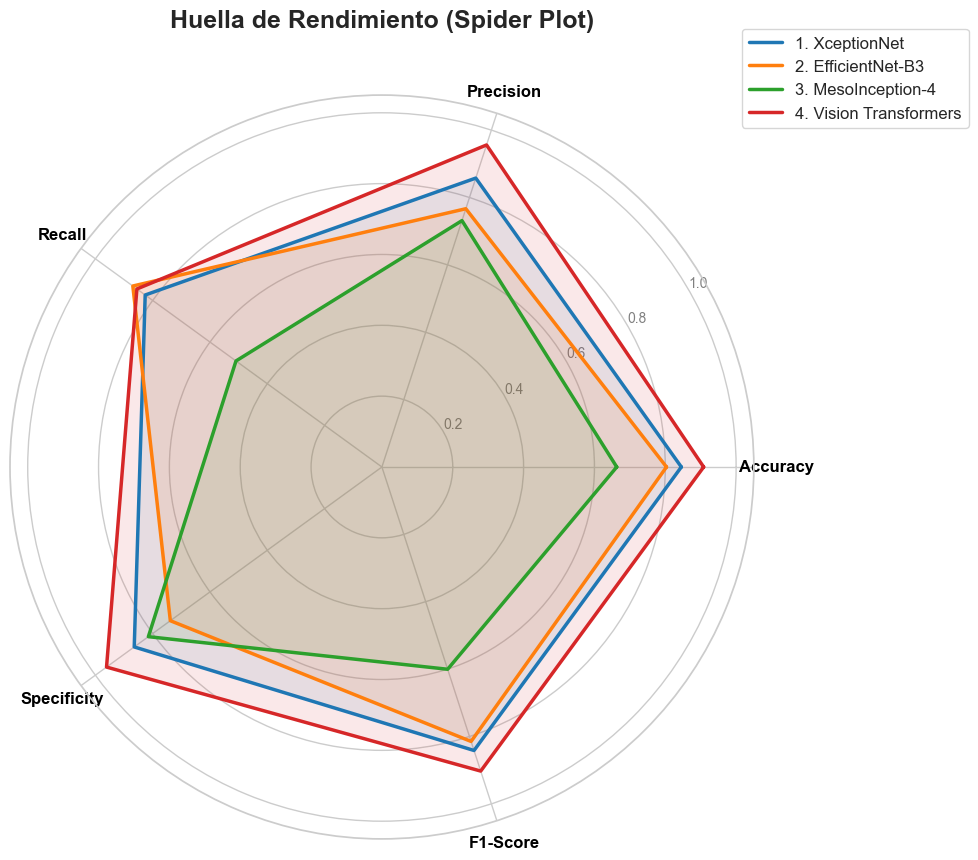

Análisis: Cuanto más área cubra el polígono hacia los bordes exteriores, mejor es el modelo en todos los frentes de forma simultánea.


In [24]:
# ==========================================
# COMPARATIVA MULTIDIMENSIONAL: GRÁFICO DE RADAR
# ==========================================
from math import pi

# Elegimos las métricas que queremos en el radar (todas deben ir de 0 a 1)
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score']
N = len(metrics_radar)

# Calculamos los ángulos de cada eje en el radar
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Cerrar el círculo

# Configuramos la figura
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
plt.title('Huella de Rendimiento (Spider Plot)', fontsize=18, fontweight='bold', y=1.08)

# Colores para los modelos
colores_radar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Dibujamos cada modelo
for idx, (modelo_nombre, row) in enumerate(df_metricas.iterrows()):
    values = row[metrics_radar].values.flatten().tolist()
    values += values[:1] # Cerrar el círculo
    
    ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=modelo_nombre, color=colores_radar[idx])
    ax.fill(angles, values, alpha=0.1, color=colores_radar[idx])

# Etiquetas de los ejes
plt.xticks(angles[:-1], metrics_radar, color='black', size=12, fontweight='bold')

# Líneas circulares de referencia (0.2, 0.4, 0.6, 0.8, 1.0)
ax.set_rlabel_position(30)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1.05)

# Leyenda
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)

plt.tight_layout()
plt.show()

print("Análisis: Cuanto más área cubra el polígono hacia los bordes exteriores, mejor es el modelo en todos los frentes de forma simultánea.")

# Mapa de Calor (Heatmap) de los resultados globales

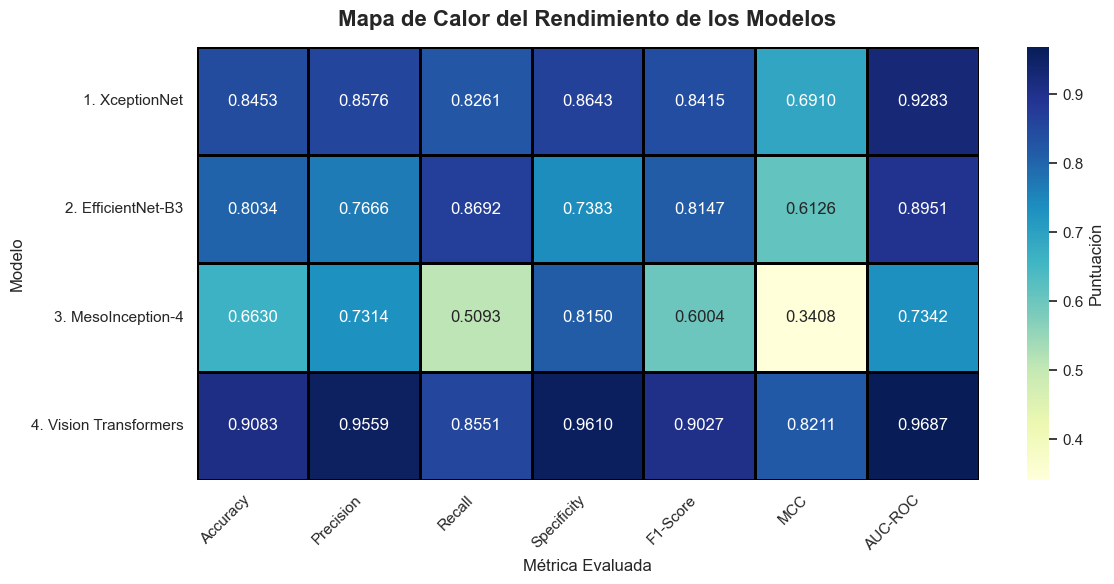

Análisis: Los tonos más oscuros indican superioridad técnica en esa métrica concreta.


In [25]:
# ==========================================
# RESUMEN VISUAL: HEATMAP DE MÉTRICAS CLAVE
# ==========================================
plt.figure(figsize=(12, 6))

# Seleccionamos solo las métricas de rendimiento positivas (más alto es mejor)
metricas_positivas = df_metricas[['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'MCC', 'AUC-ROC']]

# Dibujamos un mapa de calor
ax = sns.heatmap(metricas_positivas, annot=True, fmt=".4f", cmap="YlGnBu", 
                 linewidths=1, linecolor='black', cbar_kws={'label': 'Puntuación'})

plt.title('Mapa de Calor del Rendimiento de los Modelos', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Métrica Evaluada', fontsize=12)
plt.ylabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

print("Análisis: Los tonos más oscuros indican superioridad técnica en esa métrica concreta.")

# Extracción a excel de la tabla de métricas

In [26]:
# ==========================================
# EXPORTAR RESULTADOS A CSV Y EXCEL
# ==========================================
import os

carpeta_salida = r"C:\TFG\Resultados_Finales"
os.makedirs(carpeta_salida, exist_ok=True)

# Guardar como CSV
df_metricas.to_csv(os.path.join(carpeta_salida, "metricas_comparativa_LOSS.csv"), float_format='%.4f')

# Guardar como Excel (si tienes openpyxl instalado)
try:
    df_metricas.to_excel(os.path.join(carpeta_salida, "metricas_comparativa.xlsx"), float_format='%.4f')
    print(f"✅ Resultados guardados con éxito en: {carpeta_salida}")
except Exception as e:
    print(f"✅ CSV guardado. (Para Excel necesitas instalar openpyxl: pip install openpyxl)")

✅ CSV guardado. (Para Excel necesitas instalar openpyxl: pip install openpyxl)


# GRÁFICAS Curva ROC (Receiver Operating Characteristic)

In [27]:
# ==========================================
# 1. EXTRACCIÓN DE PROBABILIDADES PARA CURVAS ROC
# ==========================================
datos_roc = {}

print("⏳ Extrayendo probabilidades de XceptionNet...")
y_t_xc, y_p_xc, _ = run_inference(model_xc, test_loader_xc, "XceptionNet")
datos_roc['XceptionNet'] = (y_t_xc, y_p_xc)

print("⏳ Extrayendo probabilidades de EfficientNet-B3...")
y_t_eff, y_p_eff, _ = run_inference(model_eff, test_loader_eff, "EfficientNet")
datos_roc['EfficientNet-B3'] = (y_t_eff, y_p_eff)

print("⏳ Extrayendo probabilidades de MesoInception-4...")
y_t_meso, y_p_meso, _ = run_inference(model_meso, test_loader_meso, "MesoInception")
datos_roc['MesoInception-4'] = (y_t_meso, y_p_meso)

print("⏳ Extrayendo probabilidades de Vision Transformers (ViT)...")
y_t_vit, y_p_vit, _ = run_inference(model_vit, test_loader_vit, "ViT")
datos_roc['Vision Transformers'] = (y_t_vit, y_p_vit)

print("✅ ¡Todas las probabilidades guardadas con éxito!")

⏳ Extrayendo probabilidades de XceptionNet...


Inferencia XceptionNet: 100%|██████████| 187/187 [00:43<00:00,  4.31it/s]


⏳ Extrayendo probabilidades de EfficientNet-B3...


Inferencia EfficientNet: 100%|██████████| 187/187 [00:40<00:00,  4.66it/s]


⏳ Extrayendo probabilidades de MesoInception-4...


Inferencia MesoInception: 100%|██████████| 187/187 [00:21<00:00,  8.80it/s]


⏳ Extrayendo probabilidades de Vision Transformers (ViT)...


Inferencia ViT: 100%|██████████| 187/187 [00:54<00:00,  3.43it/s]

✅ ¡Todas las probabilidades guardadas con éxito!


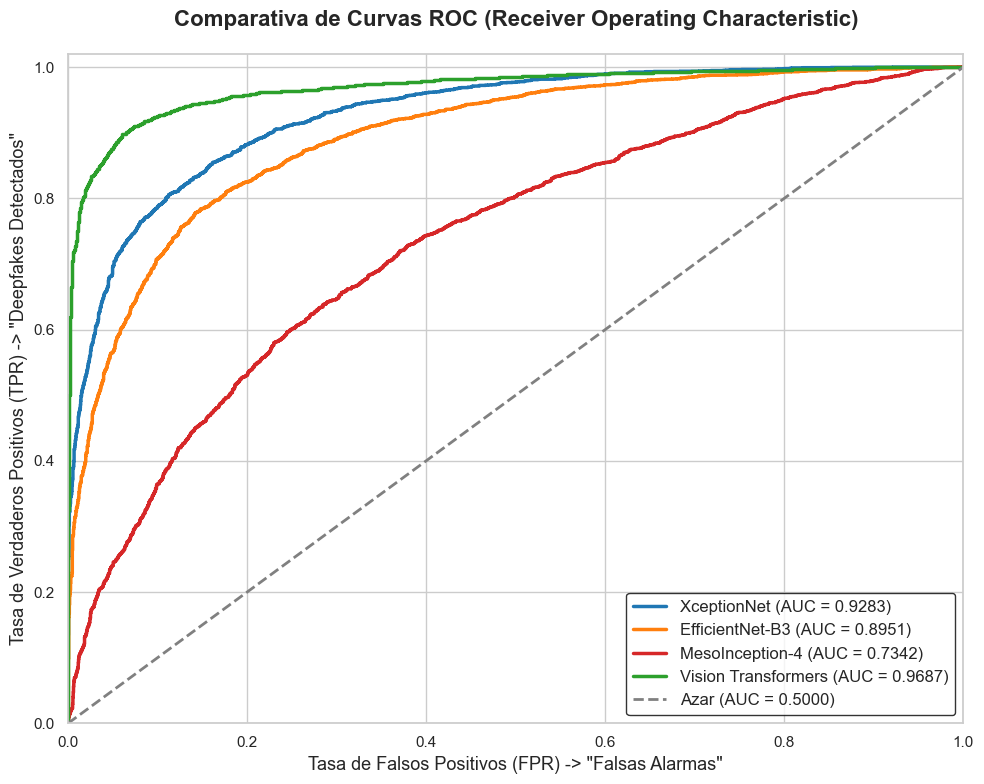

Análisis: Cuanto más se 'abrace' la curva a la esquina superior izquierda, más inteligente y preciso es el modelo. La línea gris diagonal representa un modelo inútil (lanzar una moneda al aire).


In [28]:
# ==========================================
# 2. GRÁFICA DE CURVAS ROC CONJUNTAS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Definimos colores que destaquen para cada modelo
colores_roc = {
    'XceptionNet': '#1f77b4',        # Azul
    'EfficientNet-B3': '#ff7f0e',    # Naranja
    'MesoInception-4': '#d62728',    # Rojo
    'Vision Transformers': '#2ca02c' # Verde
}

# Dibujamos la curva de cada modelo
for modelo, (y_true, y_prob) in datos_roc.items():
    # Calculamos la Tasa de Falsos Positivos (fpr) y Verdaderos Positivos (tpr)
    fpr, tpr, umbrales = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colores_roc.get(modelo, 'black'), lw=2.5, 
             label=f'{modelo} (AUC = {roc_auc:.4f})')

# Dibujamos la línea diagonal de referencia (lo que sacaría un modelo que elige al azar)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Azar (AUC = 0.5000)')

# Ajustes estéticos de la gráfica
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('Tasa de Falsos Positivos (FPR) -> "Falsas Alarmas"', fontsize=13)
plt.ylabel('Tasa de Verdaderos Positivos (TPR) -> "Deepfakes Detectados"', fontsize=13)
plt.title('Comparativa de Curvas ROC (Receiver Operating Characteristic)', fontsize=16, fontweight='bold', pad=20)

# Ponemos la leyenda en la esquina inferior derecha (es el estándar científico)
plt.legend(loc="lower right", fontsize=12, frameon=True, edgecolor='black')

plt.tight_layout()
plt.show()

print("Análisis: Cuanto más se 'abrace' la curva a la esquina superior izquierda, más inteligente y preciso es el modelo. La línea gris diagonal representa un modelo inútil (lanzar una moneda al aire).")

# Curva Precision-Recall (PR Curve)

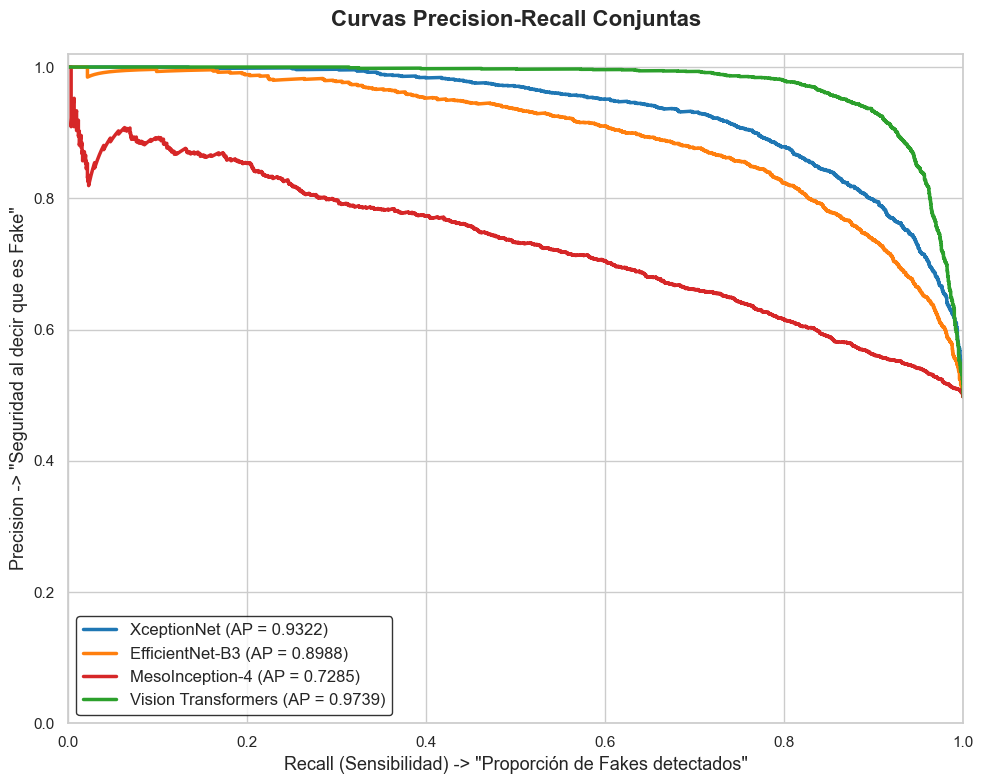

Análisis: En esta gráfica, el modelo perfecto abraza la esquina SUPERIOR DERECHA (consigue detectar todos los fakes sin cometer ninguna falsa alarma). El valor AP (Average Precision) resume el área bajo esta curva.


In [29]:
# ==========================================
# 3. CURVA PRECISION-RECALL (PR CURVE)
# ==========================================
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

for modelo, (y_true, y_prob) in datos_roc.items():
    # Calculamos Precisión y Recall para distintos umbrales
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    # Calculamos el AP (Average Precision), que es el equivalente al AUC pero en esta gráfica
    ap = average_precision_score(y_true, y_prob)
    
    plt.plot(recall, precision, color=colores_roc.get(modelo, 'black'), lw=2.5, 
             label=f'{modelo} (AP = {ap:.4f})')

# Ajustes estéticos
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('Recall (Sensibilidad) -> "Proporción de Fakes detectados"', fontsize=13)
plt.ylabel('Precision -> "Seguridad al decir que es Fake"', fontsize=13)
plt.title('Curvas Precision-Recall Conjuntas', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower left", fontsize=12, frameon=True, edgecolor='black')

plt.tight_layout()
plt.show()

print("Análisis: En esta gráfica, el modelo perfecto abraza la esquina SUPERIOR DERECHA (consigue detectar todos los fakes sin cometer ninguna falsa alarma). El valor AP (Average Precision) resume el área bajo esta curva.")

# Curvas ROC Individuales con Área Sombreada

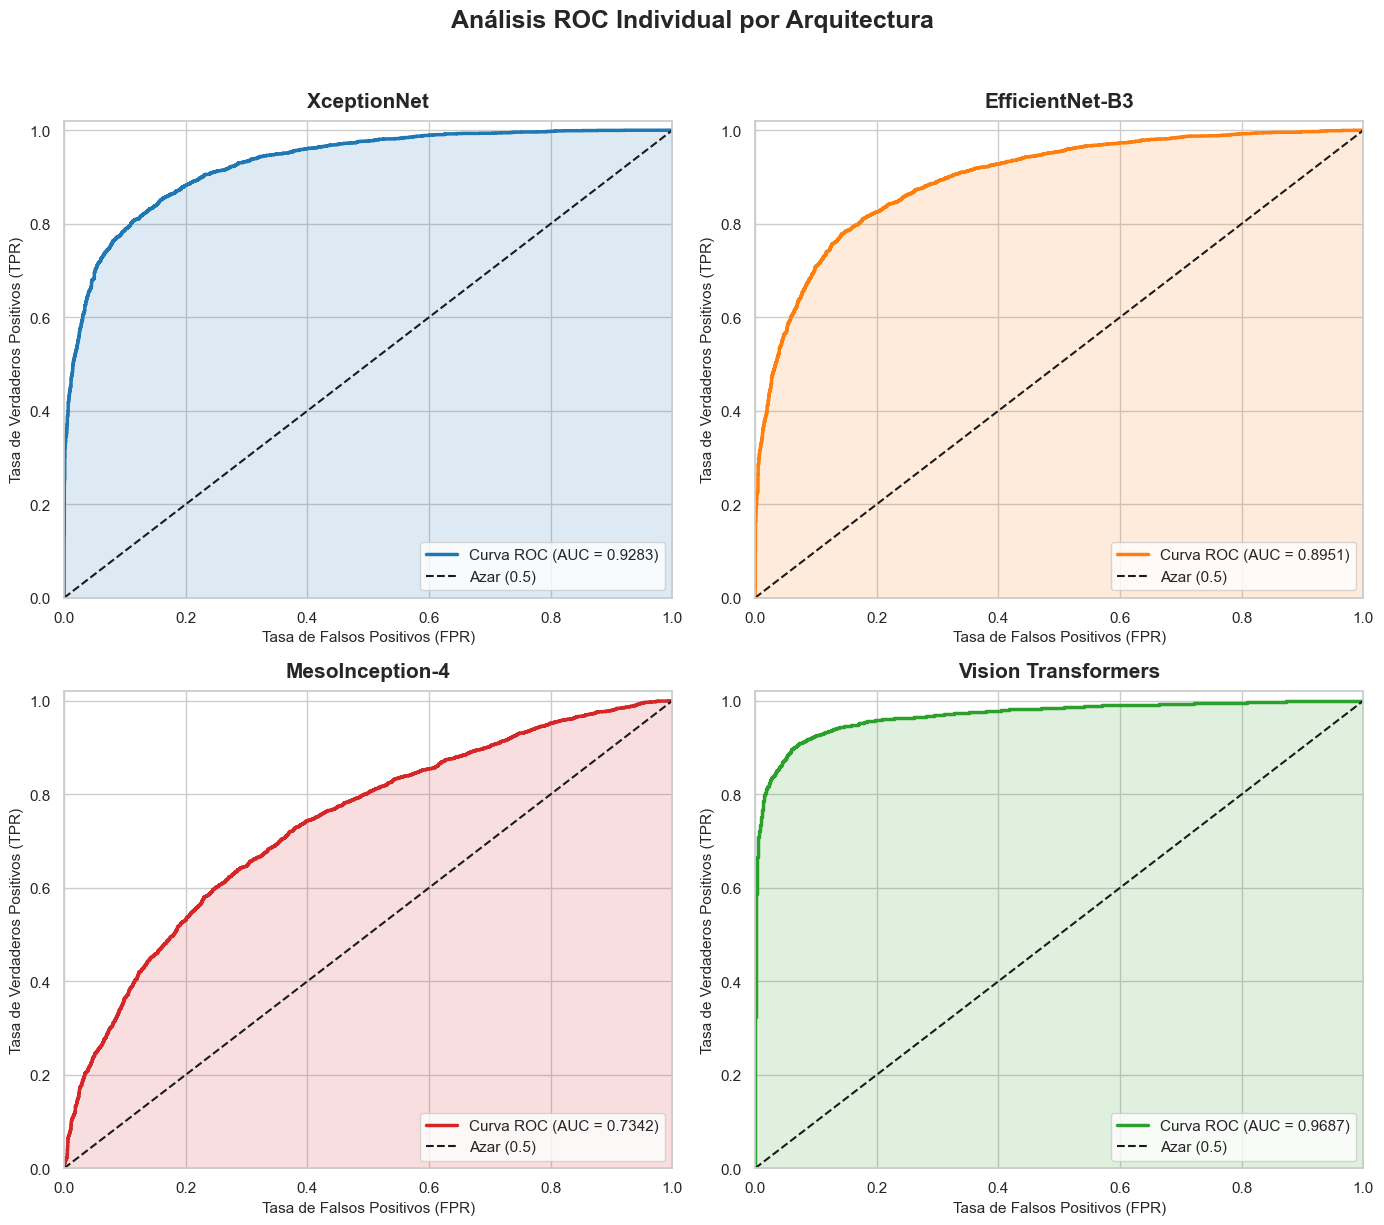

Análisis: El sombreado representa visualmente el AUC (Área Bajo la Curva). Es evidente cómo ViT y XceptionNet maximizan casi toda la superficie del cuadrante, mientras MesoInception deja un gran área sin cubrir.


In [30]:
# ==========================================
# 4. CURVAS ROC INDIVIDUALES CON ÁREA SOMBREADA
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Análisis ROC Individual por Arquitectura', fontsize=18, fontweight='bold', y=1.02)

axes = axes.flatten()

for i, (modelo, (y_true, y_prob)) in enumerate(datos_roc.items()):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    color = colores_roc.get(modelo, 'blue')
    
    # Dibujamos la curva
    axes[i].plot(fpr, tpr, color=color, lw=2.5, label=f'Curva ROC (AUC = {roc_auc:.4f})')
    
    # Sombreamos el área bajo la curva
    axes[i].fill_between(fpr, tpr, alpha=0.15, color=color)
    
    # Línea de azar
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Azar (0.5)')
    
    axes[i].set_title(modelo, fontsize=15, fontweight='bold', pad=10)
    axes[i].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
    axes[i].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.02])
    axes[i].legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

print("Análisis: El sombreado representa visualmente el AUC (Área Bajo la Curva). Es evidente cómo ViT y XceptionNet maximizan casi toda la superficie del cuadrante, mientras MesoInception deja un gran área sin cubrir.")

# Histograma de Distribución de Probabilidades (KDE Plot)

Esta gráfica responde a la pregunta: "Cuando el modelo acierta, ¿está 100% seguro o está dudando cerca del 50%?". Muestra cómo el modelo separa físicamente las imágenes Reales de los Deepfakes.

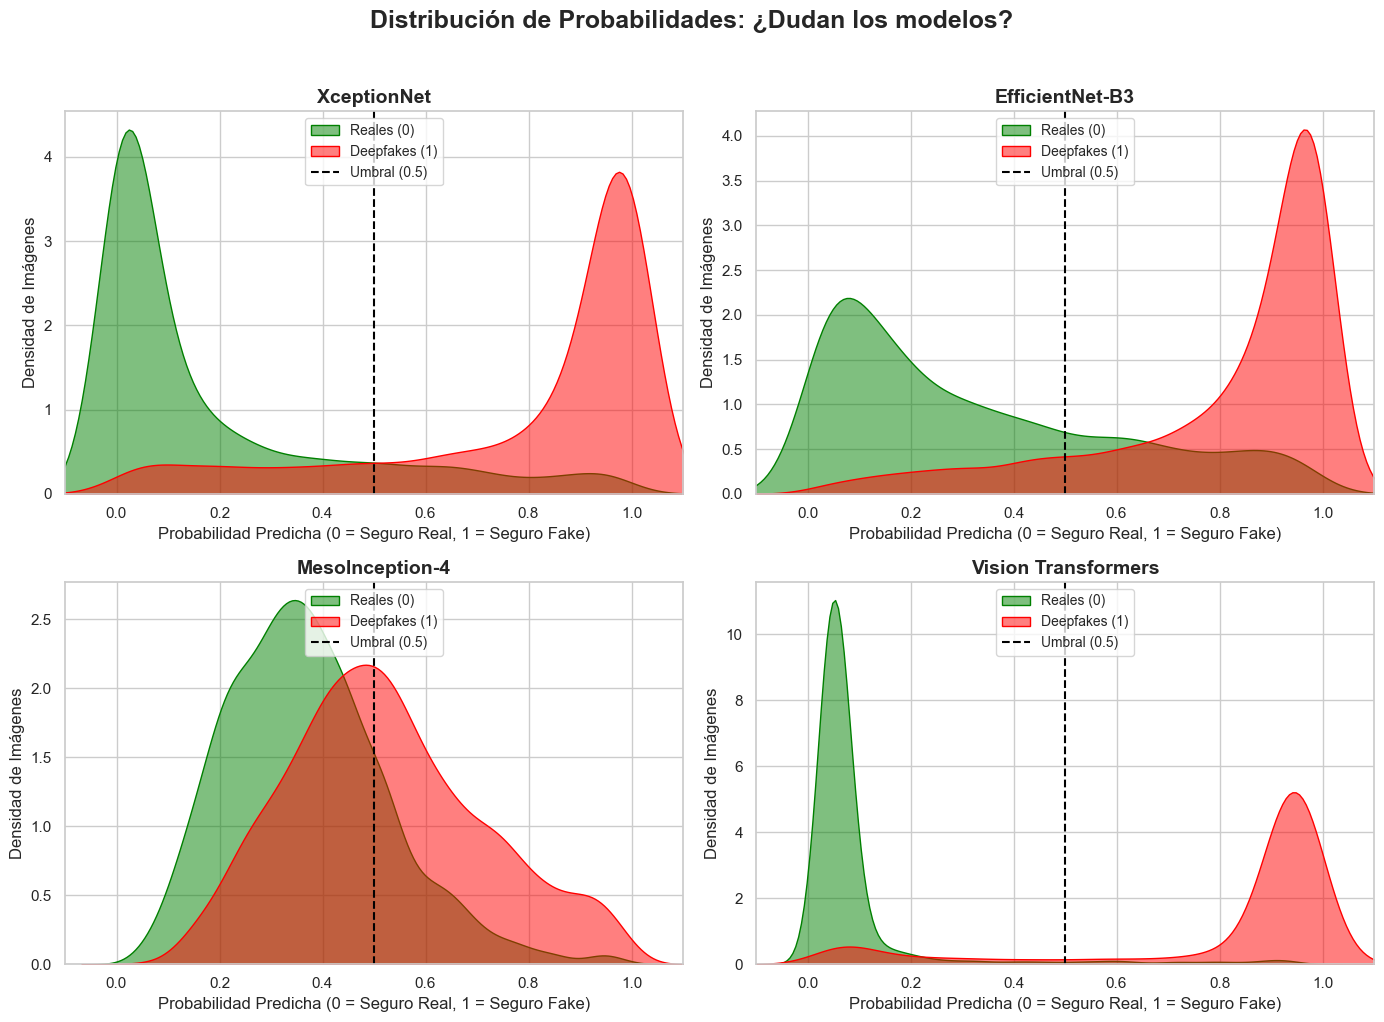

Análisis: Un modelo perfecto tendría una 'montaña' verde pegada al 0.0 y una 'montaña' roja pegada al 1.0, sin nada en medio. Si las montañas se solapan en el centro (0.5), significa que el modelo duda mucho.


In [31]:
# ==========================================
# 5. DISTRIBUCIÓN DE PROBABILIDADES (KDE PLOT)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Probabilidades: ¿Dudan los modelos?', fontsize=18, fontweight='bold', y=1.02)

axes = axes.flatten()

for i, (modelo, (y_true, y_prob)) in enumerate(datos_roc.items()):
    # Separar predicciones de imágenes reales (0) y fakes (1)
    prob_reales = [p for t, p in zip(y_true, y_prob) if t == 0]
    prob_fakes = [p for t, p in zip(y_true, y_prob) if t == 1]
    
    # Dibujar las campanas de distribución
    sns.kdeplot(prob_reales, fill=True, color='green', label='Reales (0)', ax=axes[i], alpha=0.5)
    sns.kdeplot(prob_fakes, fill=True, color='red', label='Deepfakes (1)', ax=axes[i], alpha=0.5)
    
    # Línea de umbral al 0.5
    axes[i].axvline(0.5, color='black', linestyle='--', label='Umbral (0.5)')
    
    axes[i].set_title(modelo, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Probabilidad Predicha (0 = Seguro Real, 1 = Seguro Fake)')
    axes[i].set_ylabel('Densidad de Imágenes')
    axes[i].set_xlim(-0.1, 1.1)
    axes[i].legend(loc='upper center', fontsize=10)

plt.tight_layout()
plt.show()

print("Análisis: Un modelo perfecto tendría una 'montaña' verde pegada al 0.0 y una 'montaña' roja pegada al 1.0, sin nada en medio. Si las montañas se solapan en el centro (0.5), significa que el modelo duda mucho.")

# Curva de Calibración (Reliability Diagram)

Esta es la representación visual del Brier Score y el Log Loss. Responde a una pregunta crítica en Inteligencia Artificial: "Si el modelo dice que está 80% seguro de que es un deepfake... ¿acierta realmente el 80% de las veces?"

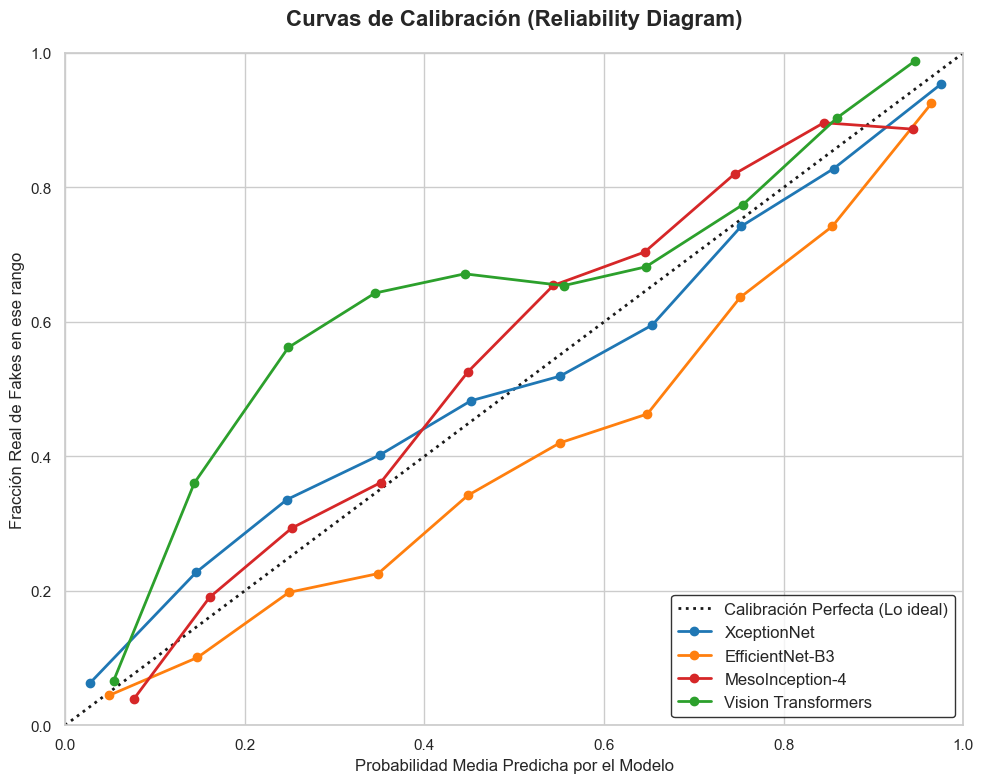

Análisis: Si la línea de un modelo está por DEBAJO de la diagonal, es 'Sobreconfiado' (cree que sabe más de lo que acierta). Si está por ENCIMA, es 'Inseguro' (acierta más de lo que cree). Lo ideal es calcar la diagonal.


In [32]:
# ==========================================
# 6. CURVA DE CALIBRACIÓN (RELIABILITY DIAGRAM)
# ==========================================
from sklearn.calibration import calibration_curve

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Línea punteada diagonal: La calibración perfecta
plt.plot([0, 1], [0, 1], "k:", label="Calibración Perfecta (Lo ideal)", lw=2)

for modelo, (y_true, y_prob) in datos_roc.items():
    # Calcular los puntos de la curva de calibración (agrupamos en 10 'cajas' de probabilidad)
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    
    plt.plot(prob_pred, prob_true, marker='o', lw=2, label=f'{modelo}', color=colores_roc.get(modelo, 'blue'))

plt.title('Curvas de Calibración (Reliability Diagram)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Probabilidad Media Predicha por el Modelo', fontsize=12)
plt.ylabel('Fracción Real de Fakes en ese rango', fontsize=12)
plt.legend(loc="lower right", fontsize=12, frameon=True, edgecolor='black')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.tight_layout()
plt.show()

print("Análisis: Si la línea de un modelo está por DEBAJO de la diagonal, es 'Sobreconfiado' (cree que sabe más de lo que acierta). Si está por ENCIMA, es 'Inseguro' (acierta más de lo que cree). Lo ideal es calcar la diagonal.")